# Trabajo Final - Probabilidad y Estadística para IA

Este notebook contiene la resolución de los tres ejercicios planteados para el Examen Final.

In [15]:
# Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Cargar archivo Excel (desde la carpeta `data/`)
data = pd.read_excel('data/Datos_TP_final_a2010.xlsx', sheet_name=None)

## 1. Análisis mensual de ventas por tienda

**Consigna:** Determinen funciones empíricas de distribución para las ventas en ambas tiendas durante cada uno de los meses del año. Determinen también aproximaciones a las funciones de densidad para las distribuciones anteriores. Determine intervalos de confianza empíricos para cada mes, para significancias del 95% y del 99%.

**Objetivo:** Analizar la distribución de ventas por mes para cada tienda y estimar funciones de densidad y sus respectivos intervalos de confianza.

In [17]:
# Cargar los datos desde el archivo Excel (hojas 'Santa Ana' y 'La Floresta')
import pandas as pd

santa_ana = pd.read_excel('data/Datos_TP_final_a2010.xlsx', sheet_name='Santa Ana')
la_floresta = pd.read_excel('data/Datos_TP_final_a2010.xlsx', sheet_name='La Floresta')

# Mostrar las primeras filas para explorar
santa_ana.head()

,Fecha,Ventas
0,2023-01-01,13738.183995
1,2023-01-02,14083.649153
2,2023-01-03,19806.572944
3,2023-01-04,19793.234963
4,2023-01-05,20918.623760


In [18]:
# Asegurar que la columna de fechas esté en formato datetime y extraer el mes
santa_ana['Fecha'] = pd.to_datetime(santa_ana['Fecha'])
la_floresta['Fecha'] = pd.to_datetime(la_floresta['Fecha'])

santa_ana['Mes'] = santa_ana['Fecha'].dt.month
la_floresta['Mes'] = la_floresta['Fecha'].dt.month

### Distribuciones empíricas mensuales
Graficamos la función empírica de distribución (ECDF) y la función de densidad (KDE) para cada mes en cada tienda.

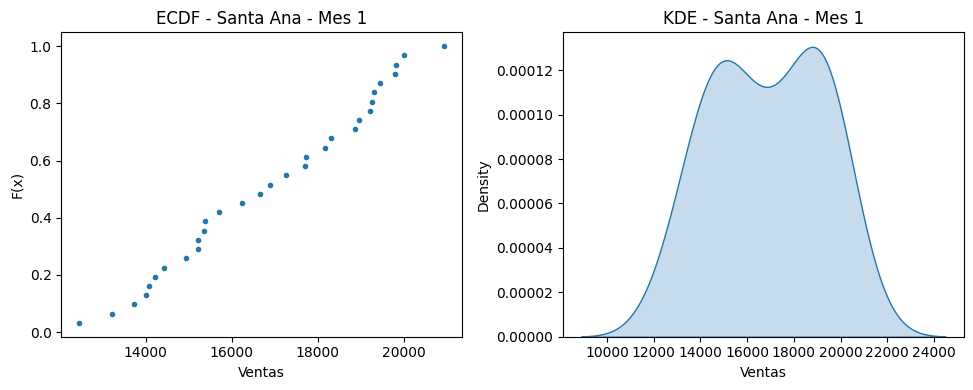

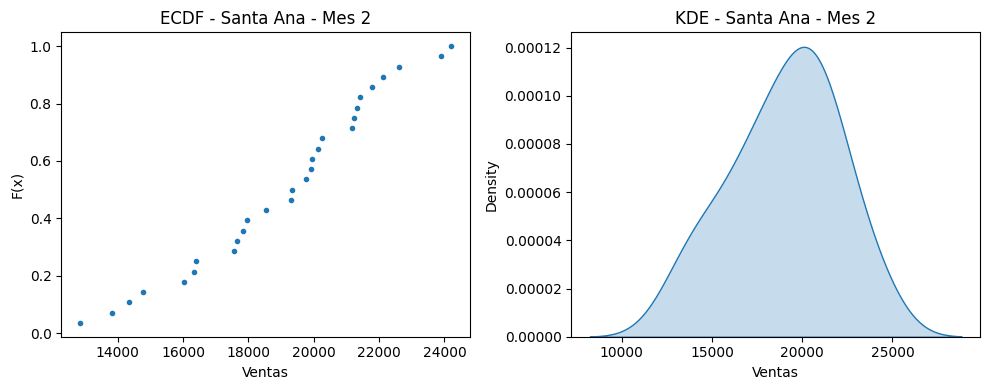

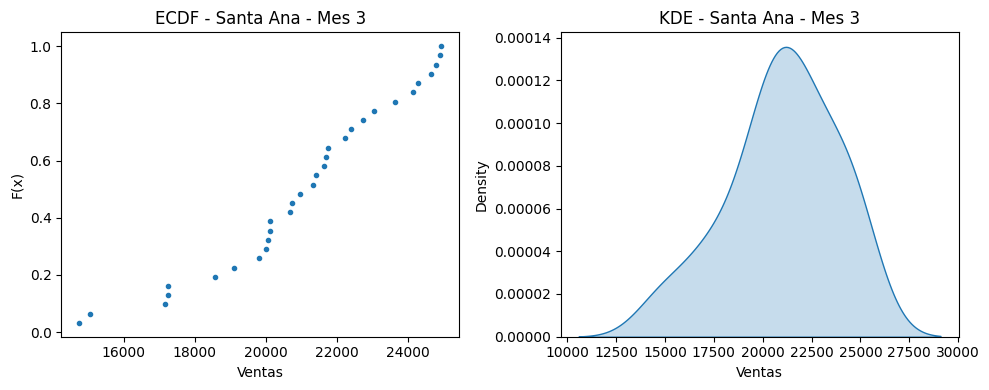

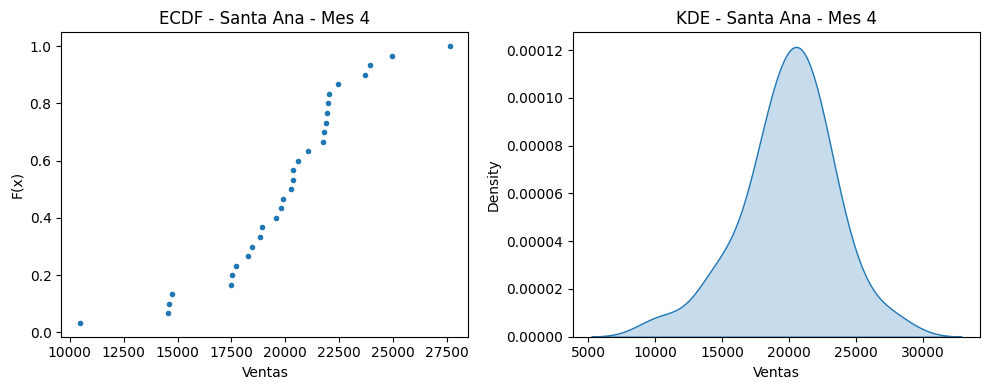

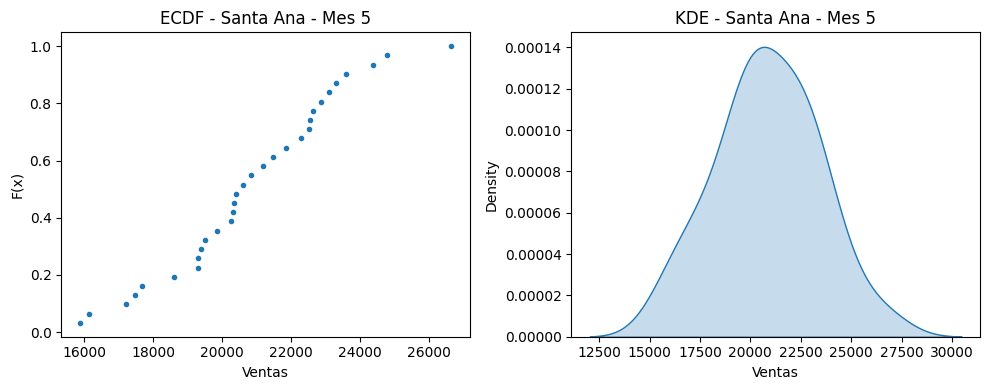

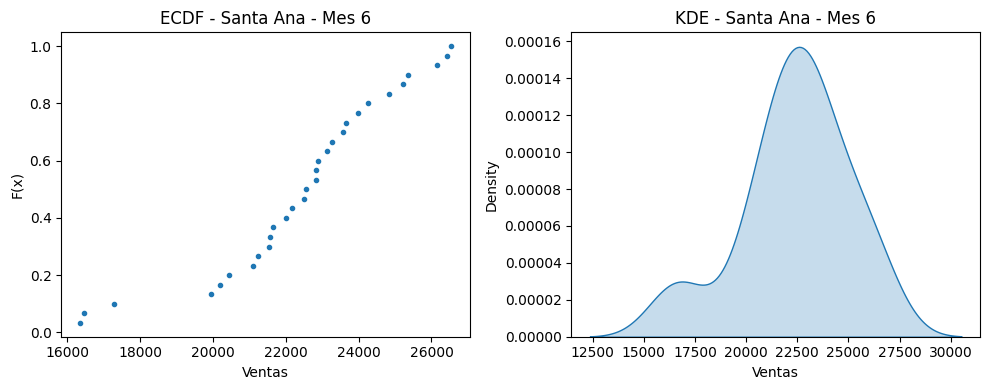

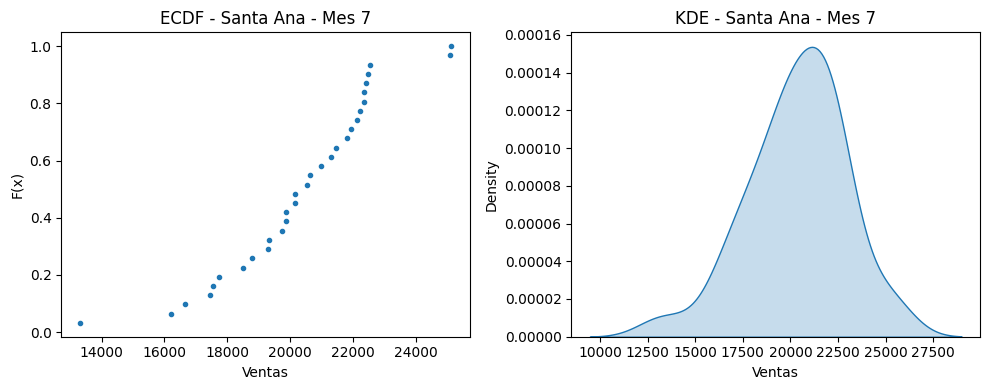

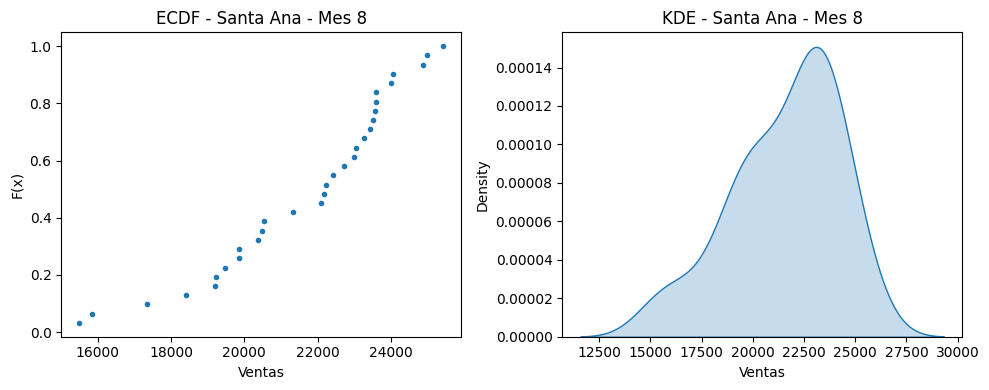

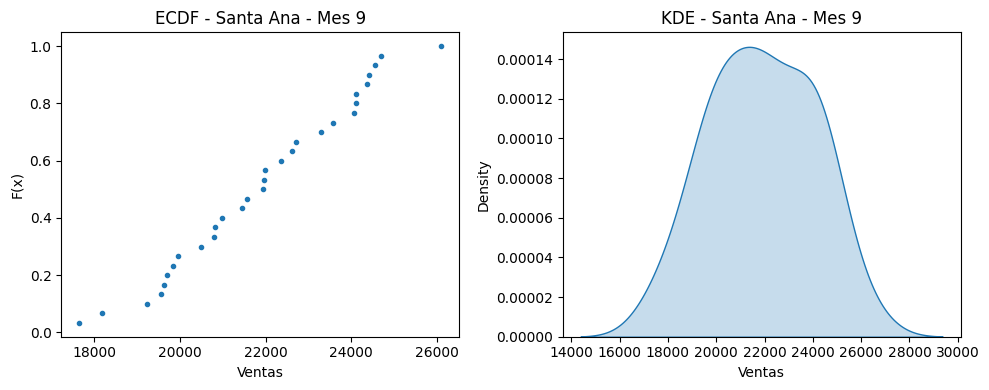

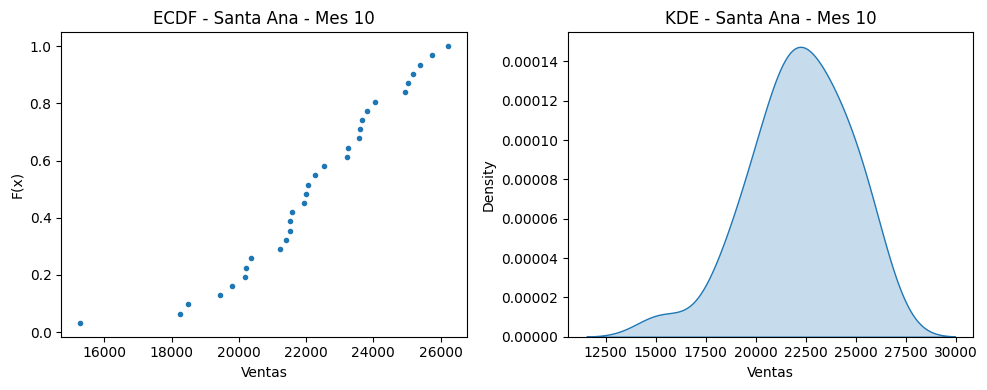

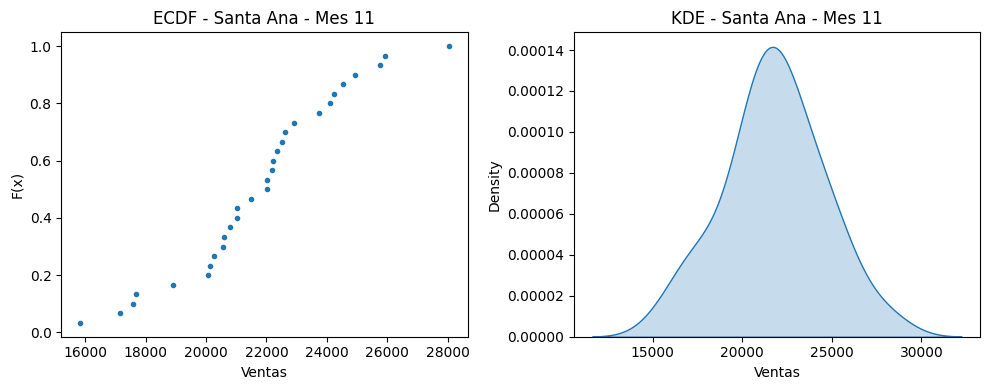

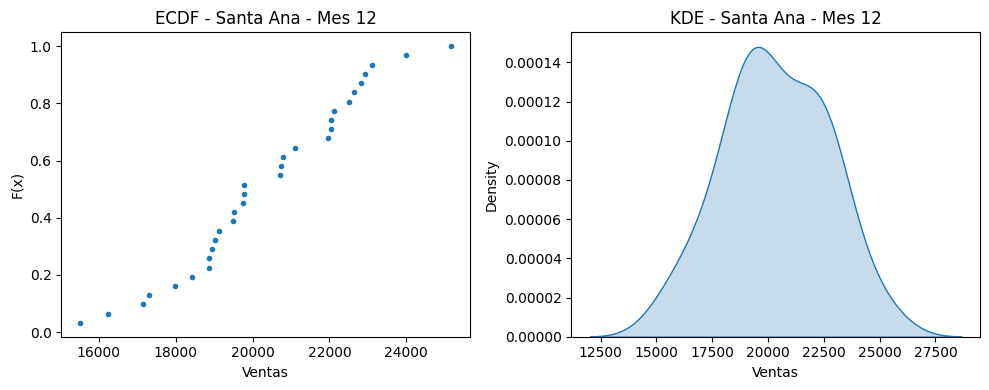

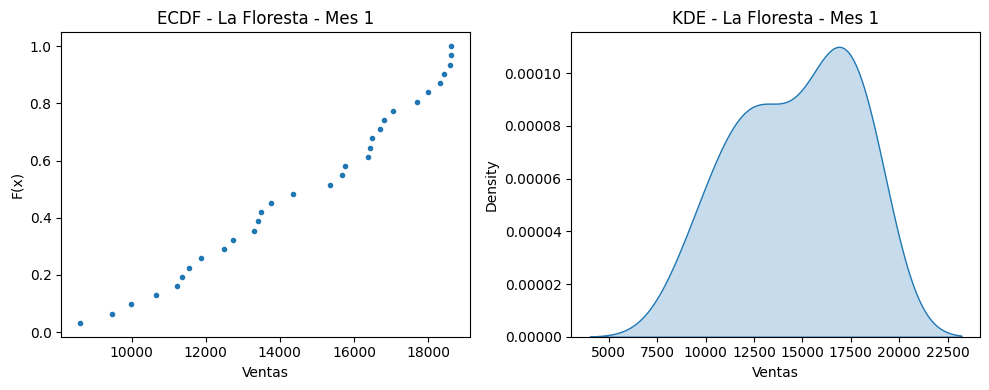

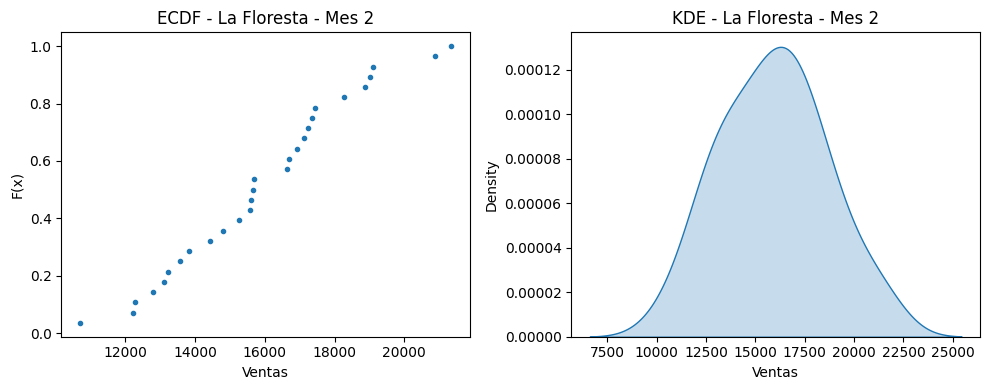

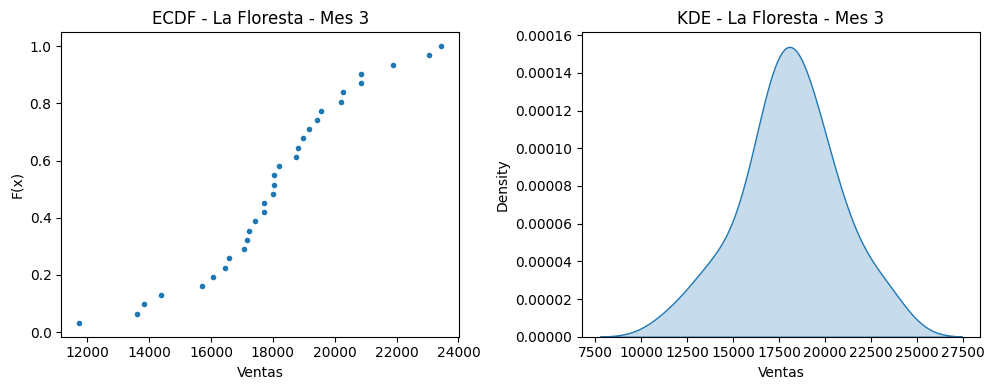

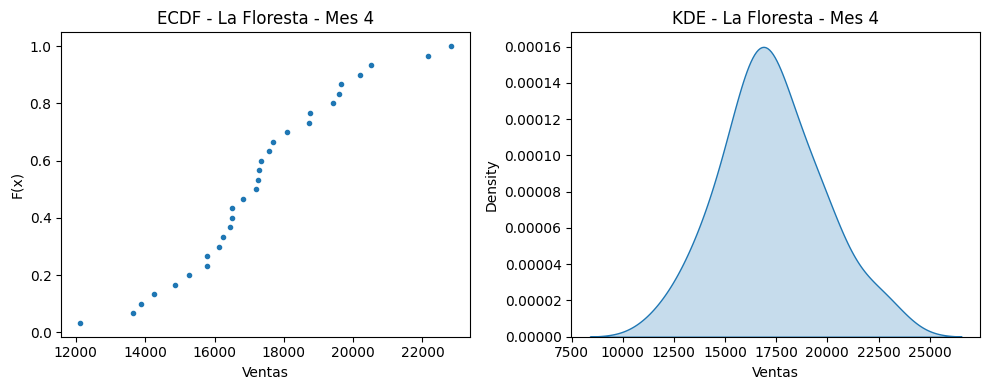

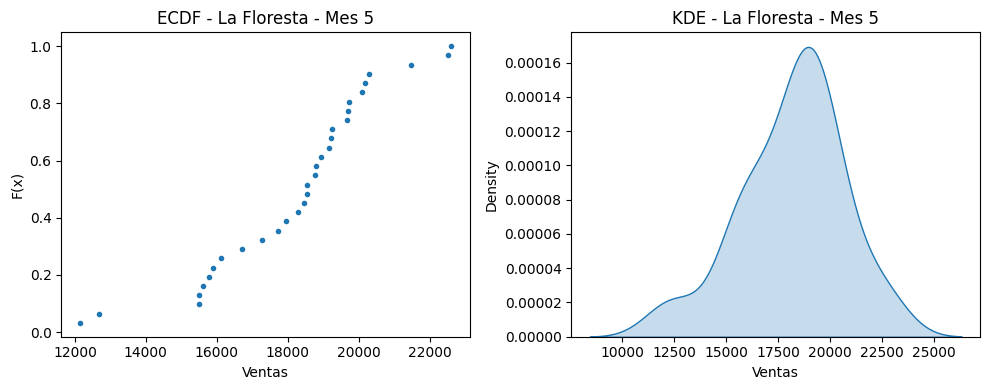

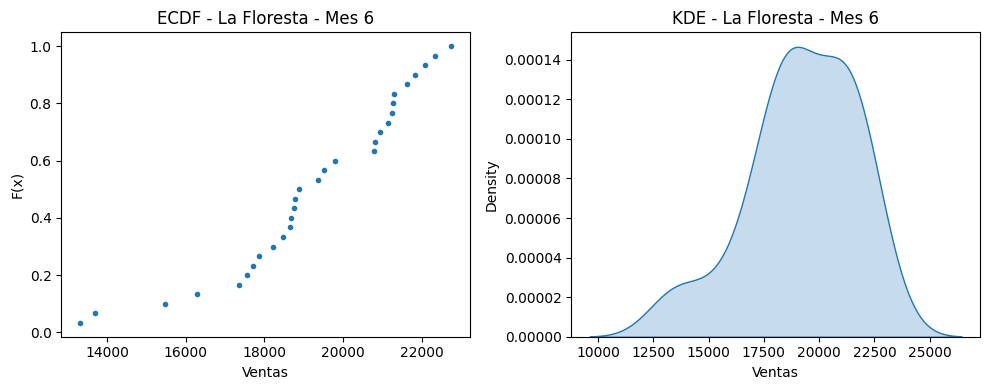

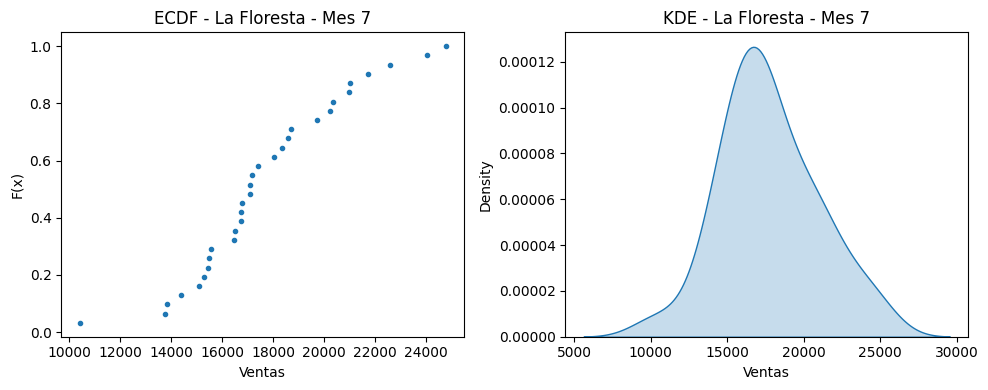

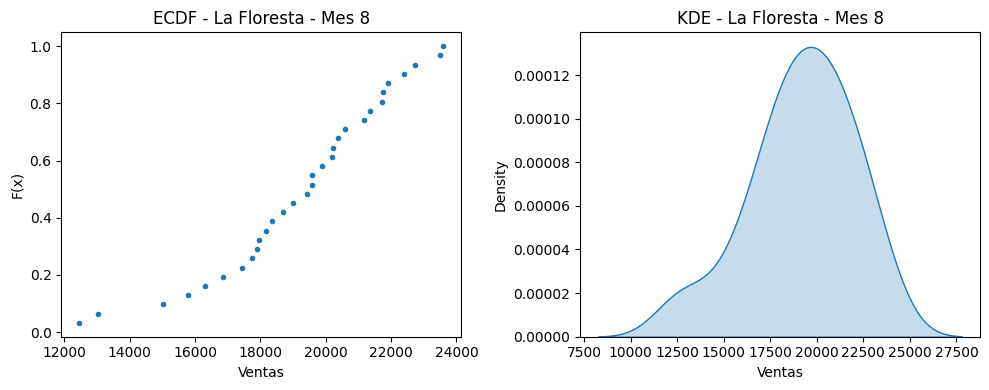

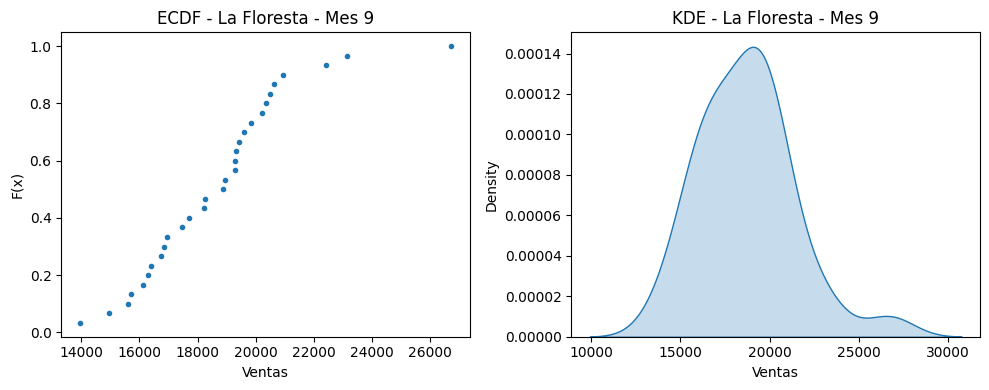

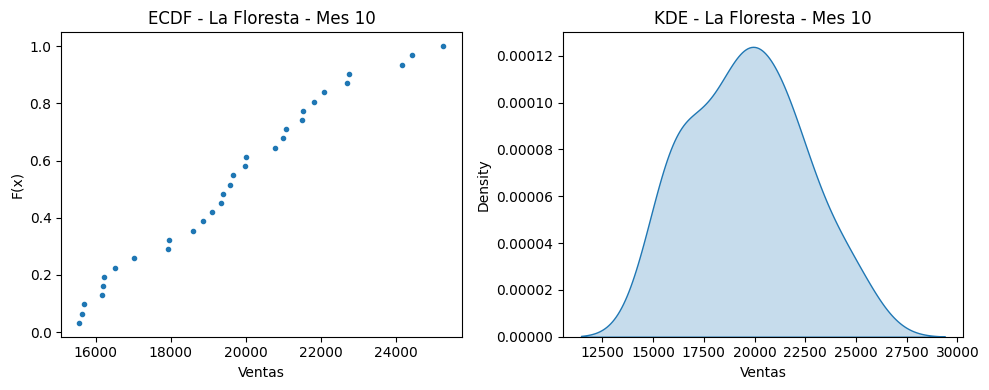

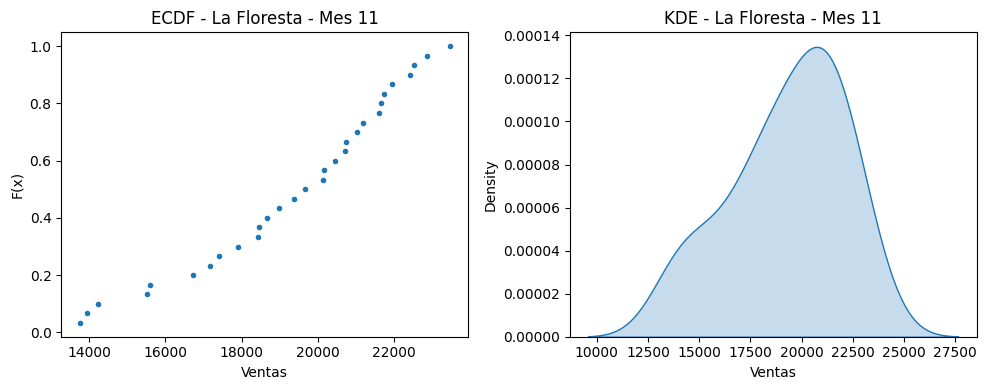

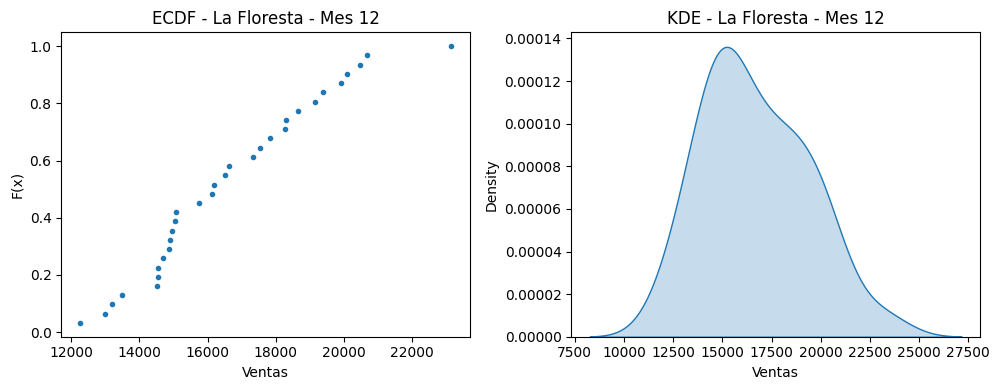

In [19]:
# Función auxiliar para graficar ECDF y KDE por mes
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.distributions.empirical_distribution import ECDF

def plot_ecdf_kde_por_mes(df, tienda):
    meses = sorted(df['Mes'].unique())
    for mes in meses:
        ventas = df[df['Mes'] == mes]['Ventas']
        ecdf = ECDF(ventas)

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(ecdf.x, ecdf.y, marker='.', linestyle='none')
        plt.title(f'ECDF - {tienda} - Mes {mes}')
        plt.xlabel('Ventas')
        plt.ylabel('F(x)')

        plt.subplot(1, 2, 2)
        sns.kdeplot(ventas, fill=True)
        plt.title(f'KDE - {tienda} - Mes {mes}')
        plt.xlabel('Ventas')
        plt.tight_layout()
        plt.show()

# Ejecutamos para ambas tiendas
plot_ecdf_kde_por_mes(santa_ana, 'Santa Ana')
plot_ecdf_kde_por_mes(la_floresta, 'La Floresta')

### Intervalos de confianza empíricos para cada mes
Calculamos los intervalos al 95% y al 99% para las ventas de cada mes usando percentiles.

In [20]:
# Función para calcular intervalos de confianza empíricos
def calcular_intervalos(df, tienda):
    resumen = []
    for mes in sorted(df['Mes'].unique()):
        ventas = df[df['Mes'] == mes]['Ventas']
        ic_95 = np.percentile(ventas, [2.5, 97.5])
        ic_99 = np.percentile(ventas, [0.5, 99.5])
        resumen.append({
            'Mes': mes,
            'Tienda': tienda,
            'IC 95%': ic_95,
            'IC 99%': ic_99
        })
    return pd.DataFrame(resumen)

intervalos_santa_ana = calcular_intervalos(santa_ana, 'Santa Ana')
intervalos_la_floresta = calcular_intervalos(la_floresta, 'La Floresta')

intervalos_santa_ana, intervalos_la_floresta

(    Mes     Tienda                                    IC 95%  \
 0     1  Santa Ana  [13035.868021401198, 20222.378714285016]   
 1     2  Santa Ana  [13509.735420811721, 24002.792225704783]   
 2     3  Santa Ana   [14977.258799660845, 24901.00424079106]   
 3     4  Santa Ana  [13425.792403425941, 25694.020449489813]   
 4     5  Santa Ana   [16076.657160370334, 25228.28988412355]   
 5     6  Santa Ana   [16425.341839802702, 26457.33322500169]   
 6     7  Santa Ana   [15477.034559428948, 25097.36653068941]   
 7     8  Santa Ana   [15752.95589242375, 25089.154845743717]   
 8     9  Santa Ana      [18039.510145388, 25087.49949293954]   
 9    10  Santa Ana   [17504.288957071516, 25874.21821213489]   
 10   11  Santa Ana   [16778.594907376704, 26509.37674826325]   
 11   12  Santa Ana   [16054.467622802336, 24292.23264626084]   
 
                                       IC 99%  
 0   [12578.868466217733, 20779.374751192878]  
 1       [12974.54430423245, 24171.928563721]  
 2   [147

In [21]:
# Función para agregar y clasificar los intervalos de confianza empíricos
def agregar_comparaciones(df):
    # Calcular promedio de IC 95% para identificar extremos
    df['Promedio IC 95%'] = df['IC 95%'].apply(lambda x: (x[0] + x[1]) / 2)
    min_mes = df.loc[df['Promedio IC 95%'].idxmin(), 'Mes']
    max_mes = df.loc[df['Promedio IC 95%'].idxmax(), 'Mes']
    
    # Clasificar cada mes
    df['Tipo de mes IC 95%'] = df['Mes'].apply(
        lambda x: 'Menores ventas' if x == min_mes else ('Mayores ventas' if x == max_mes else '-')
    )

    # Calcular promedio de IC 99% para identificar extremos
    df['Promedio IC 99%'] = df['IC 99%'].apply(lambda x: (x[0] + x[1]) / 2)
    min_mes = df.loc[df['Promedio IC 99%'].idxmin(), 'Mes']
    max_mes = df.loc[df['Promedio IC 99%'].idxmax(), 'Mes']
    
    # Clasificar cada mes
    df['Tipo de mes IC 99%'] = df['Mes'].apply(
        lambda x: 'Menores ventas' if x == min_mes else ('Mayores ventas' if x == max_mes else '-')
    )
    
    # Reordenar columnas
    return df[['Mes', 'Tienda', 'IC 95%', 'IC 99%', 'Tipo de mes IC 95%','Tipo de mes IC 99%']]

# Generar tablas para ambas tiendas
intervalos_santa_ana_tabla = agregar_comparaciones(intervalos_santa_ana.copy())
intervalos_la_floresta_tabla = agregar_comparaciones(intervalos_la_floresta.copy())

# Unir las tablas y mostrar
df_resultado = pd.concat([ intervalos_santa_ana_tabla, intervalos_la_floresta_tabla], ignore_index=True)
df_resultado

,Mes,Tienda,IC 95%,IC 99%,Tipo de mes IC 95%,Tipo de mes IC 99%
0,1,Santa Ana,"[13035.868021401198, 20222.378714285016]","[12578.868466217733, 20779.374751192878]",Menores ventas,Menores ventas
1,2,Santa Ana,"[13509.735420811721, 24002.792225704783]","[12974.54430423245, 24171.928563721]",-,-
2,3,Santa Ana,"[14977.258799660845, 24901.00424079106]","[14799.375799024074, 24918.303952663842]",-,-
3,4,Santa Ana,"[13425.792403425941, 25694.020449489813]","[11053.78415849187, 27257.76724496849]",-,-
4,5,Santa Ana,"[16076.657160370334, 25228.28988412355]","[15913.200492479464, 26356.484985183717]",-,-
5,6,Santa Ana,"[16425.341839802702, 26457.33322500169]","[16365.278579711581, 26527.604305737797]",-,-
6,7,Santa Ana,"[15477.034559428948, 25097.36653068941]","[13739.332836075855, 25131.470901360623]",-,-
7,8,Santa Ana,"[15752.95589242375, 25089.154845743717]","[15550.19490695839, 25350.251913269414]",-,-
8,9,Santa Ana,"[18039.510145388, 25087.49949293954]","[17728.689819263574, 25901.23007587562]",-,-
9,10,Santa Ana,"[17504.288957071516, 25874.21821213489]","[15711.57708296997, 26160.120464346594]",Mayores ventas,-


## 2. Análisis de ventas por día de la semana

**Consigna:** Determine funciones empíricas de distribución para las ventas en ambas tiendas por cada día de la semana. Establezcan aproximaciones a las funciones de densidad para las distribuciones anteriores. Establezcan también intervalos de confianza empíricos para cada día de la semana, para significancias del 95% y del 99%.

**Objetivo:** Evaluar cómo varían las ventas de cada tienda dependiendo del día de la semana.

In [22]:
# Agregar columna 'DíaSemana' a los datasets
santa_ana['DíaSemana'] = santa_ana['Fecha'].dt.day_name()
la_floresta['DíaSemana'] = la_floresta['Fecha'].dt.day_name()

### Distribuciones empíricas por día de la semana
Se grafican las ECDF y KDE por día de la semana para cada tienda.

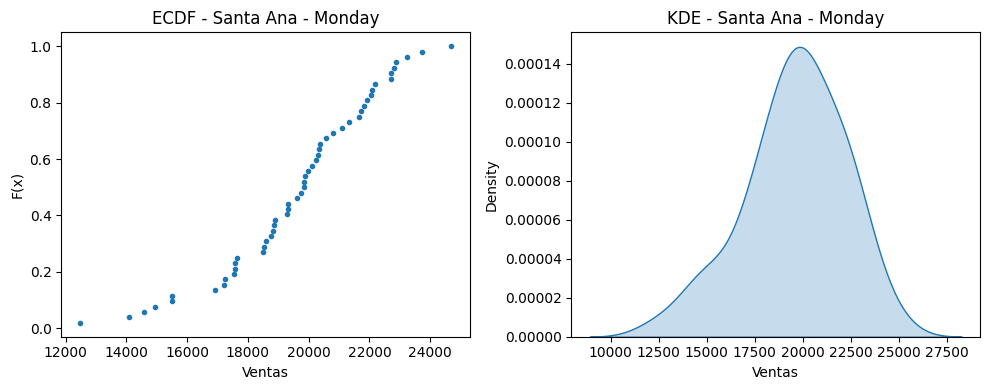

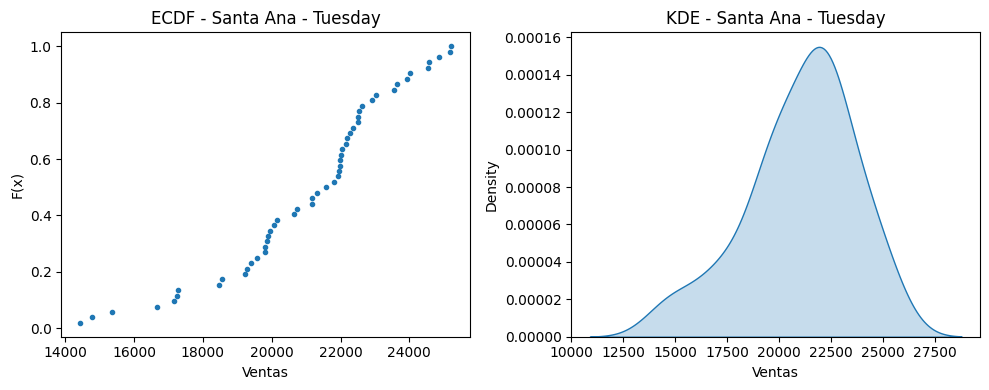

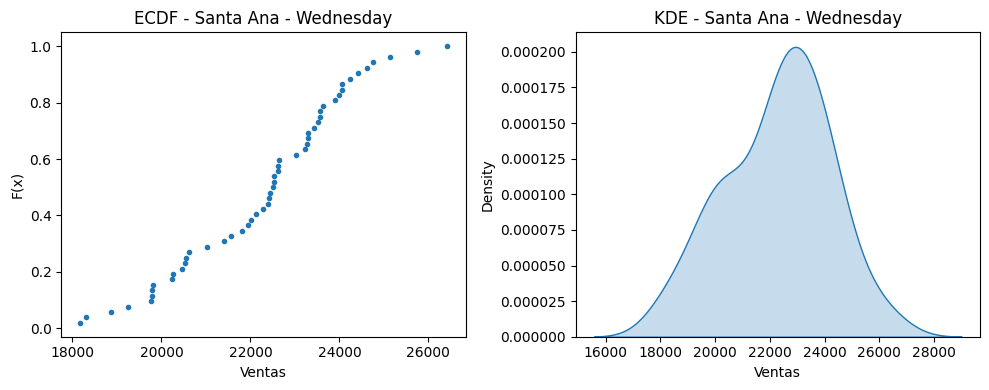

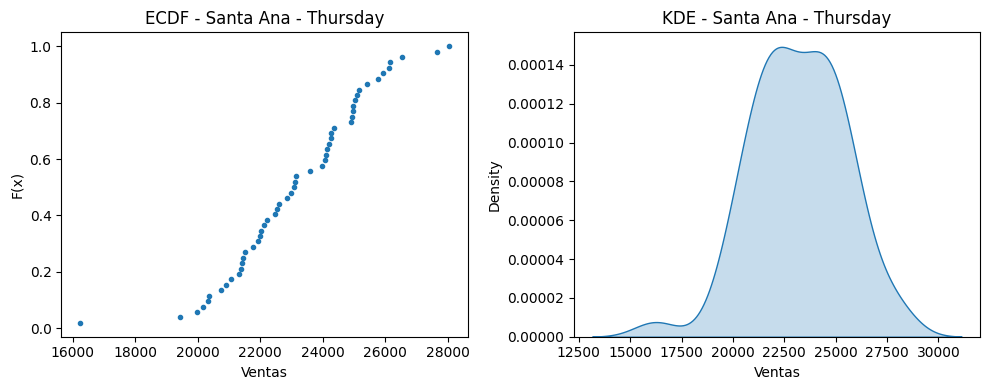

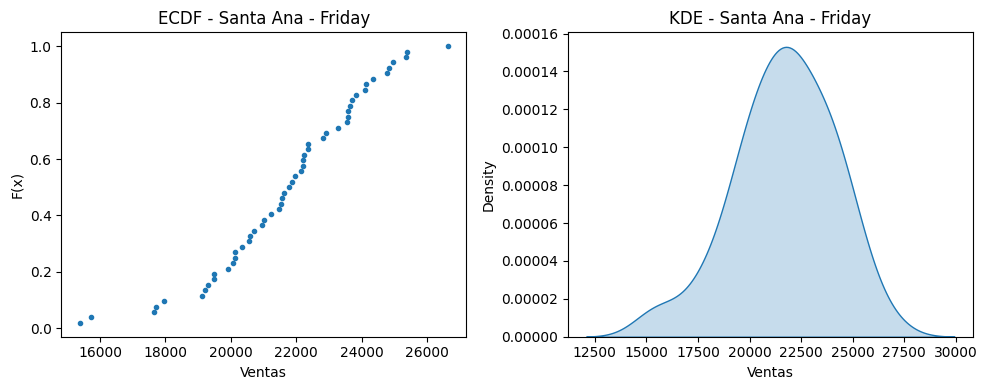

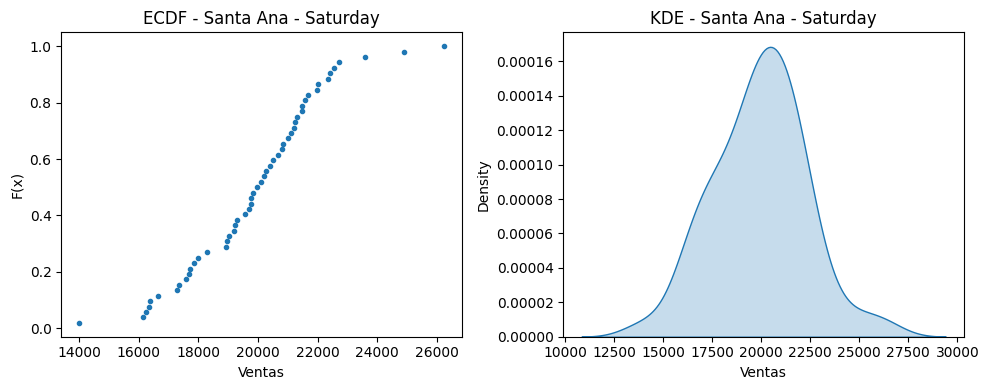

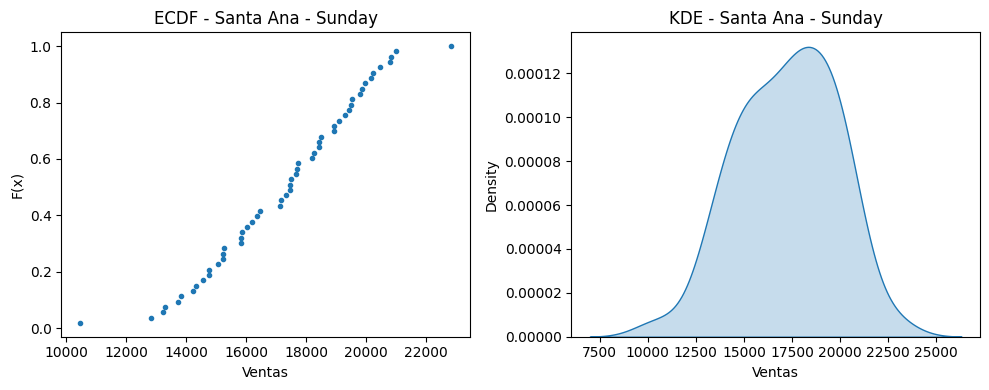

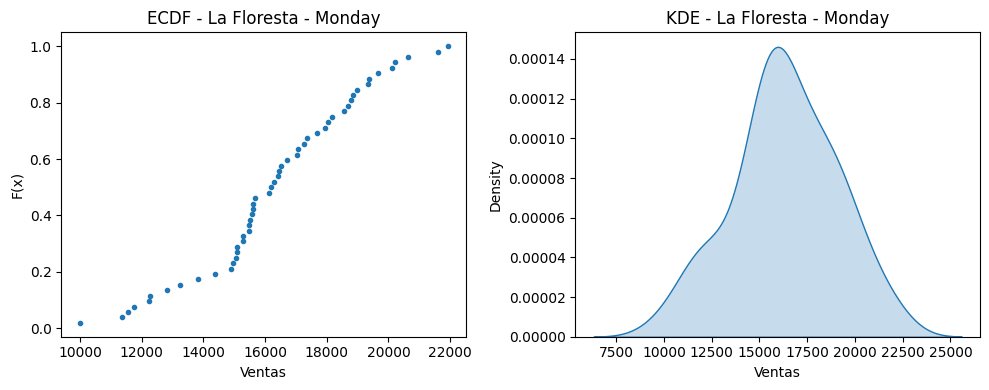

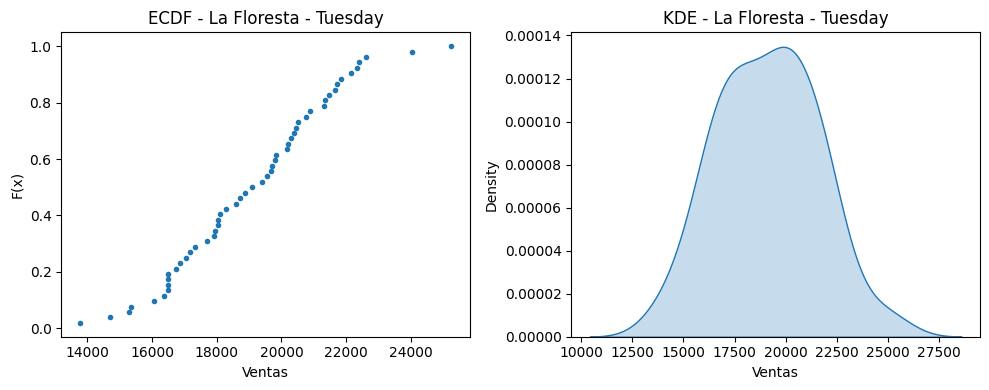

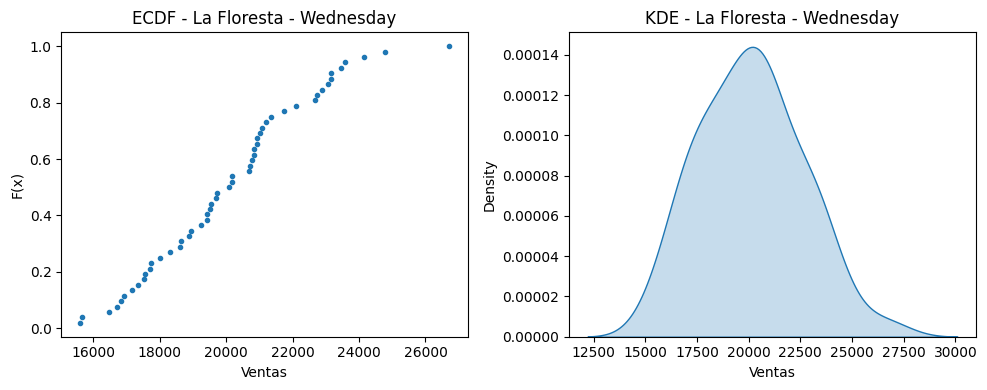

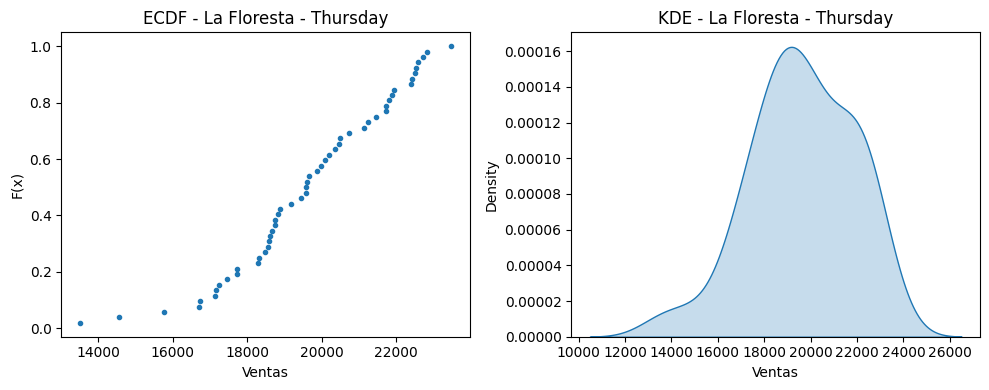

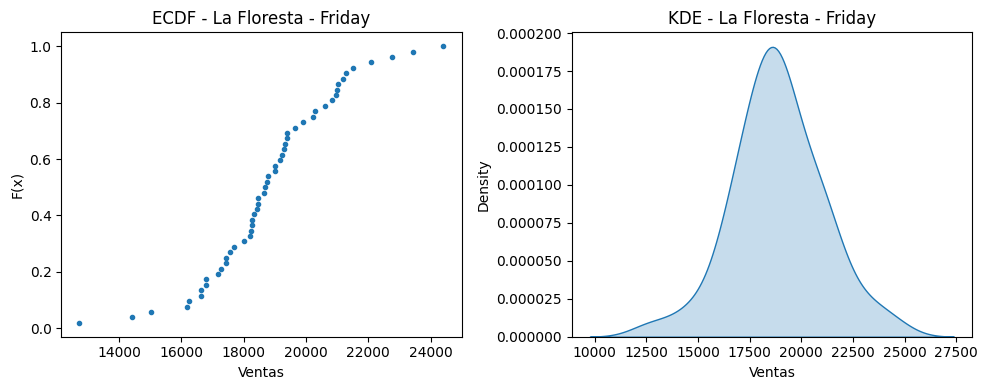

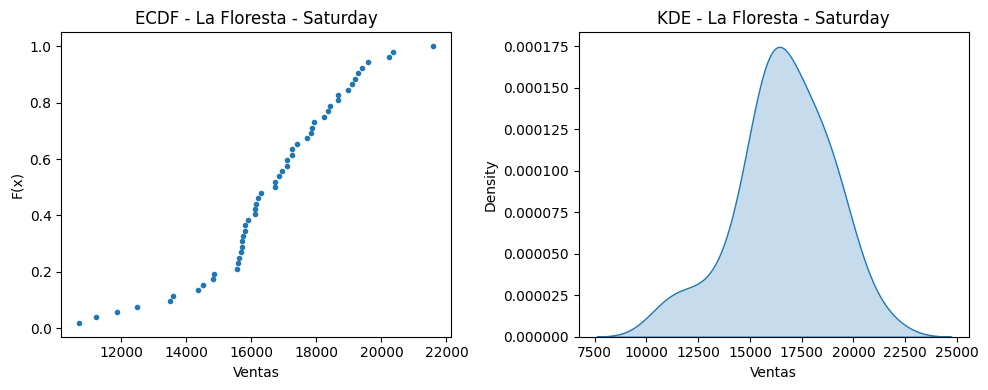

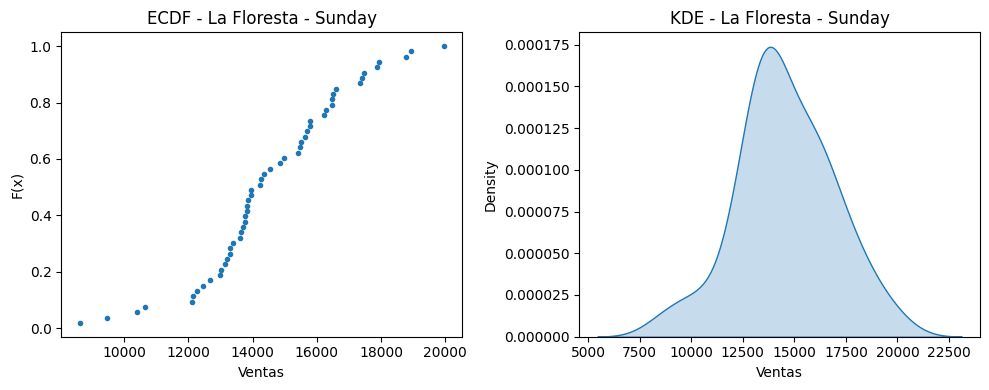

In [23]:
# Función auxiliar para graficar ECDF y KDE por día
def plot_ecdf_kde_por_dia(df, tienda):
    dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    for dia in dias:
        ventas = df[df['DíaSemana'] == dia]['Ventas']
        if ventas.empty:
            continue
        ecdf = ECDF(ventas)
        
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(ecdf.x, ecdf.y, marker='.', linestyle='none')
        plt.title(f'ECDF - {tienda} - {dia}')
        plt.xlabel('Ventas')
        plt.ylabel('F(x)')

        plt.subplot(1, 2, 2)
        sns.kdeplot(ventas, fill=True)
        plt.title(f'KDE - {tienda} - {dia}')
        plt.xlabel('Ventas')
        plt.tight_layout()
        plt.show()

# Ejecutamos para ambas tiendas
plot_ecdf_kde_por_dia(santa_ana, 'Santa Ana')
plot_ecdf_kde_por_dia(la_floresta, 'La Floresta')

### Intervalos de confianza empíricos por día
Calculamos los intervalos al 95% y al 99% para las ventas agrupadas por día de la semana.

In [24]:
# Función para calcular intervalos de confianza por día
def calcular_intervalos_dia(df, tienda):
    resumen = []
    dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    for dia in dias:
        ventas = df[df['DíaSemana'] == dia]['Ventas']
        if ventas.empty:
            continue
        ic_95 = np.percentile(ventas, [2.5, 97.5])
        ic_99 = np.percentile(ventas, [0.5, 99.5])
        resumen.append({
            'Día': dia,
            'Tienda': tienda,
            'IC 95%': ic_95,
            'IC 99%': ic_99
        })
    return pd.DataFrame(resumen)

In [25]:
# Calcular intervalos de confianza por día
intervalos_dia_santa_ana = calcular_intervalos_dia(santa_ana, 'Santa Ana')
intervalos_dia_la_floresta = calcular_intervalos_dia(la_floresta, 'La Floresta')

intervalos_dia_santa_ana, intervalos_dia_la_floresta

(         Día     Tienda                                    IC 95%  \
 0     Monday  Santa Ana  [14221.091589286321, 23598.194999567528]   
 1    Tuesday  Santa Ana  [14937.569034779464, 25091.763367236417]   
 2  Wednesday  Santa Ana   [18449.196228483346, 25584.49803089535]   
 3   Thursday  Santa Ana  [19586.533079884113, 27345.232680161167]   
 4     Friday  Santa Ana   [16240.73163519644, 25376.559091493848]   
 5   Saturday  Santa Ana   [16169.75432105323, 24552.683786941176]   
 6     Sunday  Santa Ana  [12956.407918379635, 20935.579727657514]   
 
                                      IC 99%  
 0  [12877.471374200946, 24455.657027419176]  
 1  [14513.852703281433, 25209.222333564154]  
 2     [18196.06182516766, 26252.9321824053]  
 3  [17045.198875929516, 27941.991645199116]  
 4  [15460.590195642279, 26319.815200277208]  
 5   [14559.38824009882, 25895.772928701164]  
 6   [11079.572848493965, 22357.40071998653]  ,
          Día       Tienda                                   

In [28]:
# Función para agregar y clasificar los intervalos de confianza empíricos por día de la semana
def agregar_comparaciones_dias(df):
    resultados = []

    for tienda, grupo in df.groupby('Tienda'):
        grupo = grupo.copy()
        
        # IC 95%
        grupo['Promedio IC 95%'] = grupo['IC 95%'].apply(lambda x: (x[0] + x[1]) / 2)
        min_dia_95 = grupo.loc[grupo['Promedio IC 95%'].idxmin(), 'Día']
        max_dia_95 = grupo.loc[grupo['Promedio IC 95%'].idxmax(), 'Día']
        grupo['Tipo de día IC 95%'] = grupo['Día'].apply(
            lambda x: 'Menores ventas' if x == min_dia_95 else ('Mayores ventas' if x == max_dia_95 else '-')
        )

        # IC 99%
        grupo['Promedio IC 99%'] = grupo['IC 99%'].apply(lambda x: (x[0] + x[1]) / 2)
        min_dia_99 = grupo.loc[grupo['Promedio IC 99%'].idxmin(), 'Día']
        max_dia_99 = grupo.loc[grupo['Promedio IC 99%'].idxmax(), 'Día']
        grupo['Tipo de día IC 99%'] = grupo['Día'].apply(
            lambda x: 'Menores ventas' if x == min_dia_99 else ('Mayores ventas' if x == max_dia_99 else '-')
        )

        resultados.append(grupo[['Día', 'Tienda', 'IC 95%', 'IC 99%', 'Tipo de día IC 95%', 'Tipo de día IC 99%']])
    
    return pd.concat(resultados, ignore_index=True)

In [34]:
# Generar tablas para ambas tiendas
intervalos_dia_santa_ana = calcular_intervalos_dia(santa_ana, 'Santa Ana')
intervalos_dia_la_floresta = calcular_intervalos_dia(la_floresta, 'La Floresta')

# Aplicar la función
df_dias_clasificados = agregar_comparaciones_dias(
    pd.concat([intervalos_dia_santa_ana, intervalos_dia_la_floresta], ignore_index=True)
)

# Ver el resultado
df_dias_clasificados

,Día,Tienda,IC 95%,IC 99%,Tipo de día IC 95%,Tipo de día IC 99%
0,Monday,La Floresta,"[11410.147789543778, 21349.646098828744]","[10334.071981112325, 21844.219568169083]",-,-
1,Tuesday,La Floresta,"[14858.85594373829, 23642.66630086141]","[14008.059181657325, 24942.54211442618]",-,-
2,Wednesday,La Floresta,"[15879.042040152717, 24598.643127431038]","[15604.986981409997, 26224.36458110113]",Mayores ventas,Mayores ventas
3,Thursday,La Floresta,"[14879.890538933307, 22807.113387850655]","[13767.858769291759, 23321.136415232213]",-,-
4,Friday,La Floresta,"[14585.119077875328, 23256.278142903266]","[13164.474998228054, 24164.748877686907]",-,-
5,Saturday,La Floresta,"[11408.525966527635, 20310.59835291404]","[10839.612878702812, 21279.46709851748]",-,-
6,Sunday,La Floresta,"[9747.676533355869, 18900.657400967022]","[8830.781125402958, 19699.34111466673]",Menores ventas,Menores ventas
7,Monday,Santa Ana,"[14221.091589286321, 23598.194999567528]","[12877.471374200946, 24455.657027419176]",-,-
8,Tuesday,Santa Ana,"[14937.569034779464, 25091.763367236417]","[14513.852703281433, 25209.222333564154]",-,-
9,Wednesday,Santa Ana,"[18449.196228483346, 25584.49803089535]","[18196.06182516766, 26252.9321824053]",-,-


## 3. Pruebas de hipótesis sobre intuiciones de Don Francisco

En este análisis se busca determinar si existen diferencias significativas entre las ventas de las dos tiendas: **Santa Ana** y **La Floresta**.

Para ello se procederá con:

1. Verificación de supuestos de normalidad y homogeneidad de varianzas.
2. Aplicación de ANOVA de un factor.
3. Contraste alternativo con T-test de Student.
4. Visualización mediante boxplot.

**Consigna:** Realicen pruebas de hipótesis, con base en los datos, para aceptar o rechazar la intuición de Don Francisco, con significancias del 95 % y 99 %.

**Suposición razonable:** Don Francisco intuye que **La Floresta vende menos que Santa Ana** en términos generales. Esto se traduce en una prueba de hipótesis de comparación de medias:

- **Hipótesis nula (H₀)**: La media de ventas en Santa Ana es menor o igual que en La Floresta.
- **Hipótesis alternativa (H₁)**: La media de ventas en Santa Ana es mayor que en La Floresta.

In [35]:
# Agregar columna de tienda
santa_ana['Tienda'] = 'Santa Ana'
la_floresta['Tienda'] = 'La Floresta'

# Unir los datasets
data = pd.concat([santa_ana, la_floresta], ignore_index=True)

### Estadísticas descriptivas básicas por tienda

In [36]:
data.groupby('Tienda')['Ventas'].describe()

,count,mean,std,min,25%,50%,75%,max
Tienda,,,,,,,,
La Floresta,365.0,17882.145500,3040.723094,8606.527368,15787.061961,18002.951116,19996.717526,26721.664246
Santa Ana,365.0,20681.703956,3007.621851,10460.782097,18963.834420,20918.623760,22649.632750,28042.378711


### Prueba de normalidad (Shapiro-Wilk)

In [37]:
from scipy import stats

ventas_santa_ana = santa_ana['Ventas']
ventas_la_floresta = la_floresta['Ventas']

shapiro_santa = stats.shapiro(ventas_santa_ana)
shapiro_floresta = stats.shapiro(ventas_la_floresta)

print("Shapiro Santa Ana:", shapiro_santa)
print("Shapiro La Floresta:", shapiro_floresta)

Shapiro Santa Ana: ShapiroResult(statistic=np.float64(0.9856838682241688), pvalue=np.float64(0.0011233691620308151))
Shapiro La Floresta: ShapiroResult(statistic=np.float64(0.99683383603967), pvalue=np.float64(0.6982830919052907))


### Prueba de homogeneidad de varianzas (Levene)

In [39]:
levene_test = stats.levene(ventas_santa_ana, ventas_la_floresta)
print("Levene test:", levene_test)

Levene test: LeveneResult(statistic=np.float64(0.10196210981842097), pvalue=np.float64(0.7495792147731191))


### ANOVA de un factor

In [40]:
anova = stats.f_oneway(ventas_santa_ana, ventas_la_floresta)
print("ANOVA:", anova)

ANOVA: F_onewayResult(statistic=np.float64(156.39246681213933), pvalue=np.float64(1.2057093780072587e-32))


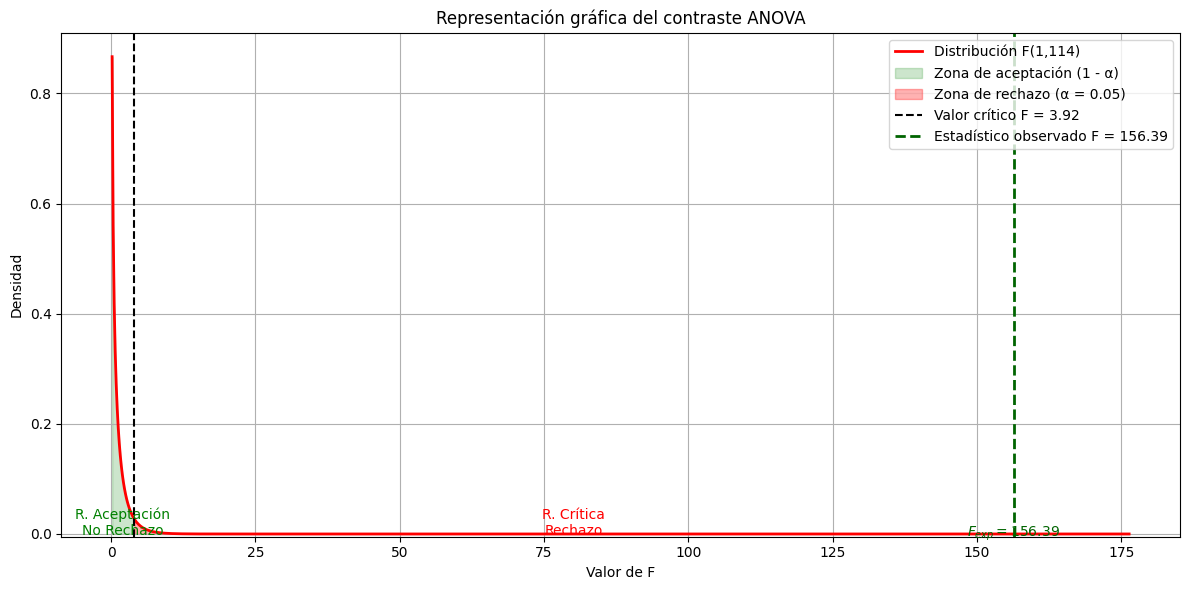

In [49]:
# Representación gráfica del contraste ANOVA
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

# Parámetros
df_between = 1
df_within = 114
alpha = 0.05
f_exp = 156.39
f_crit = f.ppf(1 - alpha, df_between, df_within)

# Rango extendido para incluir f_exp claramente
x = np.linspace(0, f_exp + 20, 1000)
y = f.pdf(x, df_between, df_within)

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(x, y, 'r-', lw=2, label=f'Distribución F({df_between},{df_within})')

# Zona de aceptación
plt.fill_between(x, 0, y, where=(x < f_crit), color='green', alpha=0.2, label='Zona de aceptación (1 - α)')
# Zona de rechazo
plt.fill_between(x, 0, y, where=(x >= f_crit), color='red', alpha=0.3, label='Zona de rechazo (α = 0.05)')

# Líneas críticas
plt.axvline(f_crit, color='black', linestyle='--', label=f'Valor crítico F = {f_crit:.2f}')
plt.axvline(f_exp, color='darkgreen', linestyle='--', lw=2, label=f'Estadístico observado F = {f_exp:.2f}')

# Texto inferior para regiones
plt.text(f_crit / 2, -0.002, 'R. Aceptación\nNo Rechazo', color='green', ha='center', fontsize=10)
plt.text((f_crit + f_exp) / 2, -0.002, 'R. Crítica\nRechazo', color='red', ha='center', fontsize=10)
plt.text(f_exp, -0.004, '$F_{exp} = 156.39$', color='darkgreen', ha='center', fontsize=10)

# Estética
plt.title('Representación gráfica del contraste ANOVA')
plt.xlabel('Valor de F')
plt.ylabel('Densidad')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.ylim(bottom=-0.005)
plt.show()


### Análisis de resultados
Interpretamos los resultados con base en los niveles de significancia planteados:

- Si **p < 0.05**, se rechaza H₀ al 95% de confianza.
- Si **p < 0.01**, se rechaza H₀ al 99% de confianza.

Según el valor p obtenido, indicamos si hay evidencia suficiente para respaldar la intuición de Don Francisco de que *Santa Ana* vende más que *La Floresta*. Se rechaza la hipótesis nula de que la media de ventas en Santa Ana es menor o igual que en La Floresta.

### T-test de Student (varianzas desiguales)

In [41]:
ttest = stats.ttest_ind(ventas_santa_ana, ventas_la_floresta, equal_var=False)
print("T-test:", ttest)

T-test: TtestResult(statistic=np.float64(12.505697374082724), pvalue=np.float64(1.2066564245638598e-32), df=np.float64(727.9127975200126))


### Visualización: Distribución de ventas por tienda

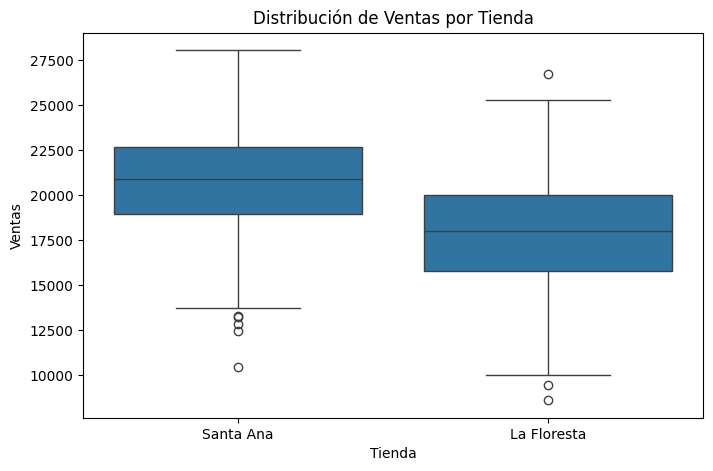

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(x='Tienda', y='Ventas', data=data)
plt.title('Distribución de Ventas por Tienda')
plt.savefig('results/boxplot_ventas_tienda.png')
plt.show()